# Comparison between the different altimetric product
- surface + 15m depth
- $\Delta T$<3h
- Gradient compute from the duacs speed


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, compute_variance, extract_mean_geo

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

In [2]:
import numpy as np

# Generate

In [3]:
dt = 3
distance_to_coast_max = 20e3

In [4]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot250m',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [ 
    base_dic, 
]

l = [
    'L3-250m-duacsv',
]


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = dict(dt='12h', 
            drifter_preprocess = '',
            drifter_preprocess_param='',
            alti_product_key='swot250m',
            alti_diff_method = 'fromduacsv',
            alti_diff_method_param = '',
            ggd_var = 'fromduacsv',
            wd_product_key = 'era5', 
            wd_model ='rio', 
            wd_depth = '15')
comb_list = [    
    base_dic, 
]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((abs(DS.ggde)<1e-4) & (abs(DS.ggdn)<1e-4), drop=True)
DS = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

# Closure figs
#ds = compute_mean_square(DS)/U2
ds = compute_variance(DS)/U2
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')


349647
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
349647
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


In [5]:
DS = DS.isel(row_number = slice(1000, 10000))

In [6]:
DSt = extract_mean_geo(DS, dirname = ('e', 'n'))

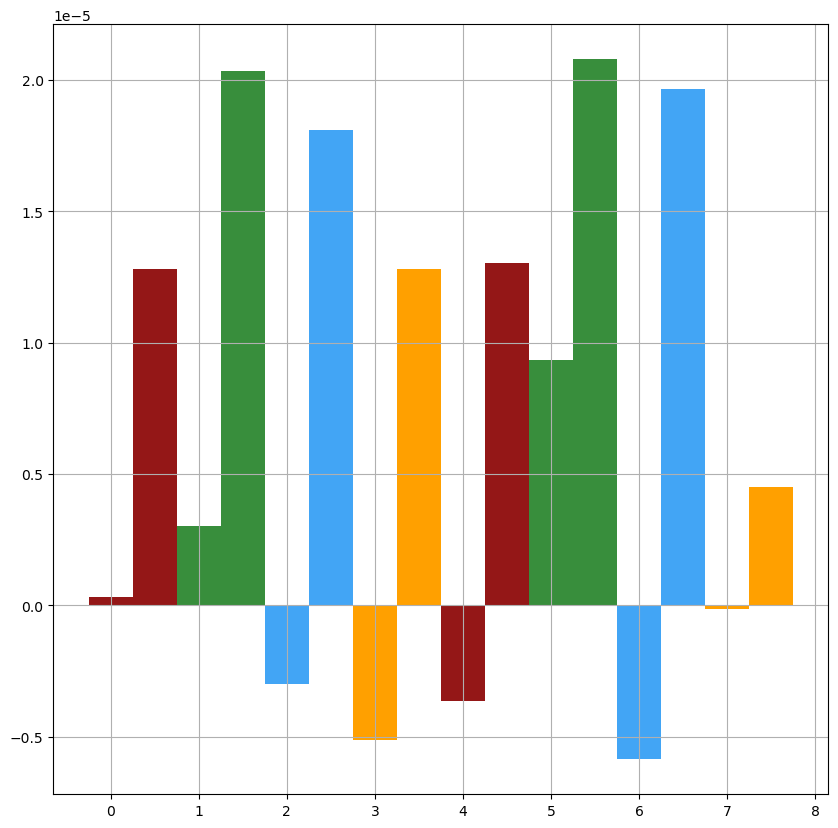

In [7]:
i = 0
fig, ax = plt.subplots(figsize = (10, 10))
for dir_ in ['e', 'n']:
    for v in ['acc', 'cor', 'ggd', 'wd']:
        ax.bar(i, DS[v+dir_].mean('row_number').values, color=c0[v], width=0.5)
        ax.bar(i+0.5, DS[v+dir_].std('row_number').values, color=c0[v], width=0.5)
        i+=1
ax.grid()

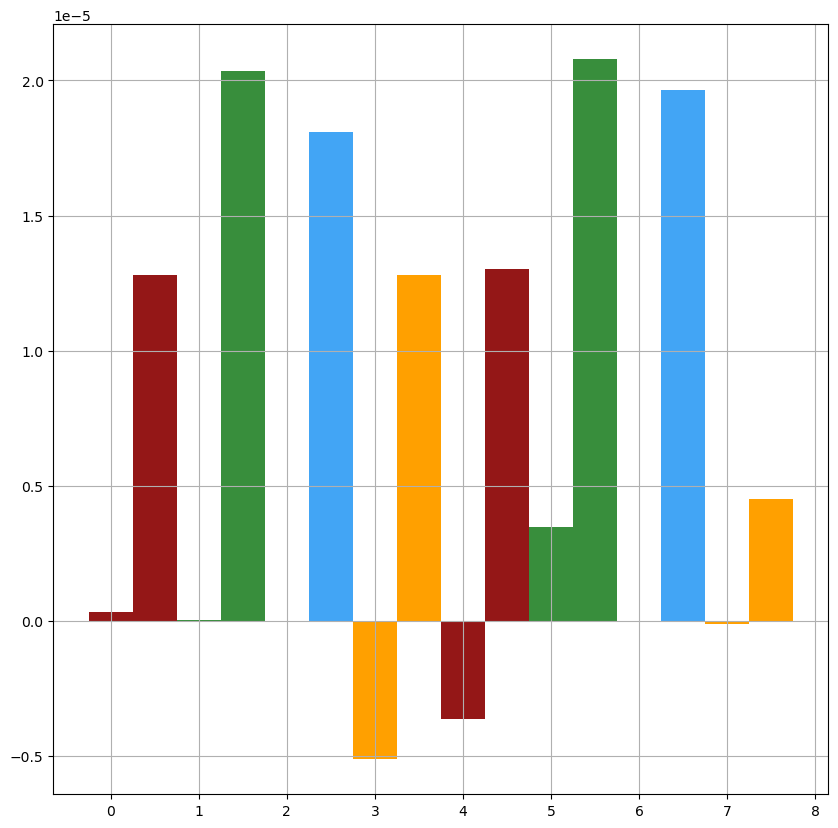

In [8]:
i = 0
fig, ax = plt.subplots(figsize = (10, 10))
for dir_ in ['e', 'n']:
    for v in ['acc', 'cor', 'ggd', 'wd']:
        ax.bar(i, DSt[v+dir_].mean('row_number').values, color=c0[v], width=0.5)
        ax.bar(i+0.5, DSt[v+dir_].std('row_number').values, color=c0[v], width=0.5)
        i+=1
ax.grid()

In [9]:
df = (compute_mean_square(DS)/U2).to_dataframe()

In [10]:
DSt

<xarray.Dataset> Size: 3MB
Dimensions:            (id_comb: 1, row_number: 9000)
Coordinates: (12/13)
    datetime           (id_comb, row_number) datetime64[ns] 72kB 2023-04-06T2...
    longitude          (id_comb, row_number) float64 72kB 4.619 4.62 ... 5.128
    latitude           (id_comb, row_number) float64 72kB 41.1 41.1 ... 40.99
    pass_number        (id_comb, row_number) int64 72kB 3 3 3 3 3 ... 3 3 3 3 3
    time_to_swot       (id_comb, row_number) timedelta64[ns] 72kB 02:15:41.86...
    cycle_number       (id_comb, row_number) int64 72kB 483 483 483 ... 512 512
    ...                 ...
    drifter_type       (id_comb, row_number) object 72kB 'MELODI' ... 'CARTHE'
    depth              (id_comb, row_number) int64 72kB 0 0 0 0 0 ... 0 0 0 0 0
    phi                (id_comb, row_number) float64 72kB 0.2348 ... 0.241
    distance_to_coast  (row_number) float64 72kB 1.204e+05 ... 1.319e+05
  * row_number         (row_number) int64 72kB 8647 8648 8649 ... 108464 108465
  * id_comb            (id_comb) <U14 56B 'L3-250m-duacsv'
Data variables: (12/35)
    sume               (id_comb, row_number) float64 72kB -7.852e-06 ... -2.6...
    acce               (id_comb, row_number) float64 72kB 1.774e-05 ... -1.40...
    exce_acc           (id_comb, row_number) float64 72kB -2.559e-05 ... -1.2...
    core               (id_comb, row_number) float64 72kB -1.49e-05 ... 4.847...
    exce_cor           (id_comb, row_number) float64 72kB 7.047e-06 ... -3.13...
    ggde               (id_comb, row_number) float64 72kB -9.897e-06 ... -1.7...
    ...                 ...
    prodn_ggd_wd       (id_comb, row_number) float64 72kB -8.443e-12 ... 6.85...
    comb               (id_comb, row_number) object 72kB '12h_spectral_decomp...
    meancore           (id_comb) float64 8B 2.974e-06
    meanggde           (id_comb) float64 8B -2.974e-06
    meancorn           (id_comb) float64 8B 5.854e-06
    meanggdn           (id_comb) float64 8B -5.854e-06

In [20]:
dft = (compute_mean_square(DSt)/U2).to_dataframe().reset_index()

ok


23.437730335608144
25.88509480951135
22.11538080351225
24.505955603497853


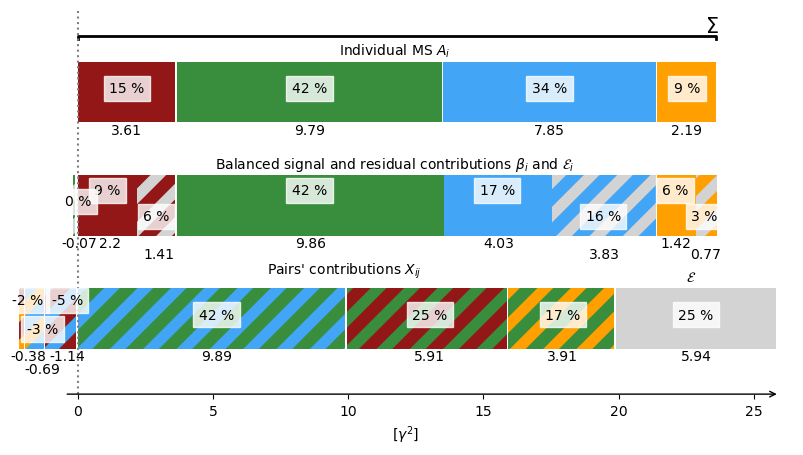

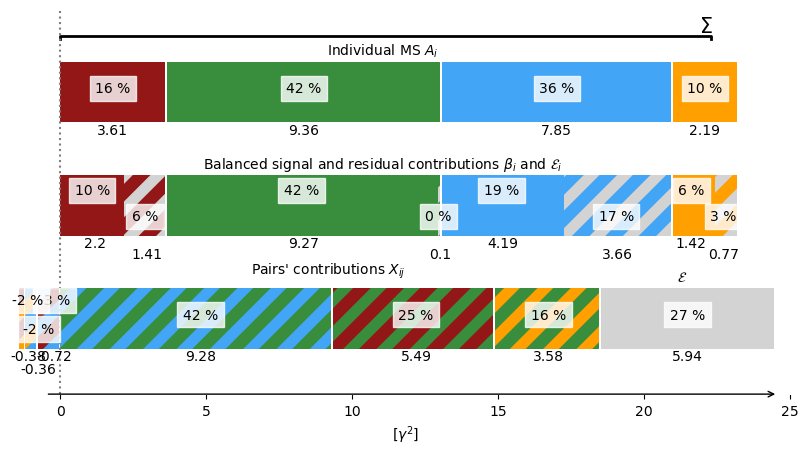

In [21]:
fig, ax = plt.subplots(figsize=(10,5))
synthetic_figure(df.iloc[0], ax, dir = '')

fig, ax = plt.subplots(figsize=(10,5))
synthetic_figure(dft.iloc[0], ax, dir = '')

In [13]:
dfc =dft.copy()

In [23]:
dfv = (compute_variance(DS)/U2).to_dataframe().reset_index()

21.576342593244597
40.37323318545519


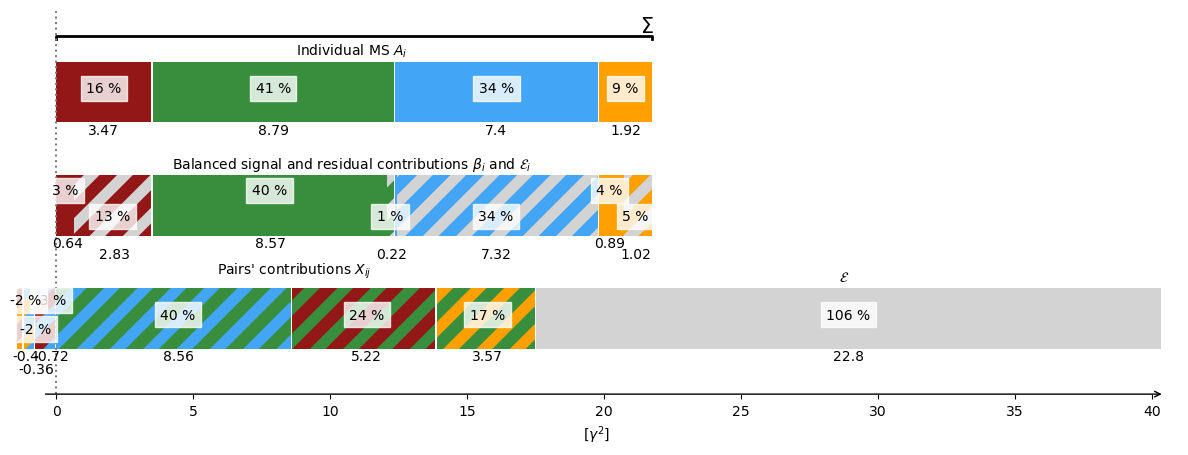

In [24]:
fig, ax = plt.subplots(figsize=(15,5))
synthetic_figure(dfv.iloc[0], ax, dir = '')